In [1]:
from pythtb import TBModel, Mesh, WFArray

import numpy as np
import matplotlib.pyplot as plt
from pythtb.models import haldane

In [2]:
model = haldane(0, 1, 0.15)

In [3]:
model.chern()

np.float64(-1.0000000000000002)

In [4]:
mesh = Mesh(dim_k=2, axis_types=['k','k'])
mesh.build_grid(shape=(50, 50))
wfa = WFArray(model.lattice, mesh)
wfa.solve_model(model)

In [5]:
wfa.chern_num(state_idx=[1])

np.float64(1.0000000000000002)

In [6]:
# Finite OBC patch: (Lx, Ly) supercell
Lx, Ly = 40, 24
fin = model.make_finite(periodic_dirs=[0,1], num_cells=[Lx, Ly])

In [7]:
C_local = fin.local_chern_marker()

Bulk Chern (trim=8.0): -0.999   (expect ~ -1.0)


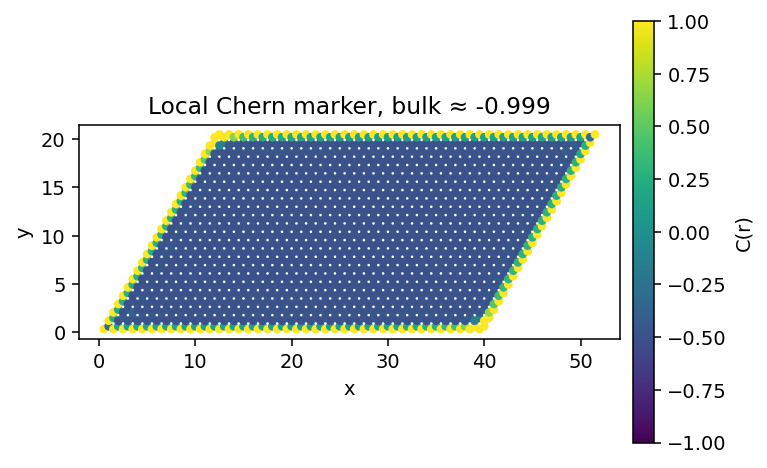

In [8]:
# 4) Aggregate per unit cell, trim, and compute bulk value
norb = 2
N = C_local.size
Ncells = N // norb

# group (assumes cut_piece ordering is cell-major then orbitals)
C_cell = C_local.reshape(Ncells, norb).sum(axis=1)

# cell centers (for trimming)
coords = fin.get_orb_vecs(cartesian=True).reshape(Ncells, norb, 2).mean(axis=1)
xmin, xmax = coords[:,0].min(), coords[:,0].max()
ymin, ymax = coords[:,1].min(), coords[:,1].max()
trim = 8.0  # in Cartesian coordinate units
mask = (coords[:,0] > xmin+trim) & (coords[:,0] < xmax-trim) & \
       (coords[:,1] > ymin+trim) & (coords[:,1] < ymax-trim)

C_bulk = C_cell[mask].mean()
print(f"Bulk Chern (trim={trim}): {C_bulk:.3f}   (expect ~ -1.0)")

# 5) Plot heatmap (site-level) and save
pos = fin.get_orb_vecs(cartesian=True)
fig, ax = plt.subplots(figsize=(6, 4.6), dpi=140)
sc = ax.scatter(pos[:,0], pos[:,1], c=C_local, s=12, vmin=-1, vmax=1)
ax.set_aspect('equal', 'box')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Local Chern marker, bulk ≈ {C_bulk:.3f}')
plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85, label='C(r)')